In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import least_squares
from scipy.stats import norm

# For Equipment

In [2]:
# Read only the column names (first row)
data2023 = pd.read_csv(fr"atusact-2023/atusact_2023.dat", dtype={'TRCODE': str, 'TUCASEID': str})
respondents2023 = pd.read_csv(fr"atusresp-2023/atusresp_2023.dat", usecols=['TUCASEID', 'TUDIARYDAY','TUFINLWGT'],dtype={'TUCASEID': str})
jointed_data2023 = pd.merge(data2023, respondents2023, on='TUCASEID', how='inner')
data2024 = pd.read_csv(fr"atusact-2024/atusact_2024.dat", dtype={'TRCODE': str, 'TUCASEID': str})
respondents2024 = pd.read_csv(fr"atusresp-2024/atusresp_2024.dat", usecols=['TUCASEID', 'TUDIARYDAY','TUFINLWGT'],dtype={'TUCASEID': str})
joined_data2024 = pd.merge(data2024, respondents2024, on='TUCASEID', how='inner')
joined_data = pd.concat([jointed_data2023, joined_data2024], ignore_index=True)

## Cooking

In [4]:
cooking = joined_data.where(joined_data['TRCODE'].astype(str) == '020201').dropna()

In [ ]:

weight_sum = sum(cooking['TUFINLWGT'])
print(f"Total weight sum: {weight_sum}")

# 1. Setup Data (Assume 'cooking' is your dataframe)
# Ensure we are working with numeric duration
df = cooking[['TUACTDUR', 'TUFINLWGT']].copy()

# 2. Sort by the value you want to filter (Duration)
df = df.sort_values(by='TUACTDUR')

# 3. Calculate Cumulative Weights to find the true 98% Cutoff
cumsum_weights = df['TUFINLWGT'].cumsum()
total_weight = df['TUFINLWGT'].sum()
df['cumulative_percent'] = cumsum_weights / total_weight

# 4. Find the value at the 98th percentile mark
# We look for the first row where cumulative percent >= 0.98
cutoff_value = df.loc[df['cumulative_percent'] >= 0.98, 'TUACTDUR'].iloc[0]

print(f"98th Percentile Cutoff: {cutoff_value} minutes")

# 5. Filter the data (Keep everything <= cutoff)
clean_df = df[df['TUACTDUR'] <= cutoff_value].copy()

# 6. Calculate Weighted Stats on the CLEAN data
clean_values = clean_df['TUACTDUR']
clean_weights = clean_df['TUFINLWGT']

# Weighted Mean
weighted_mean = np.average(clean_values, weights=clean_weights)

# Weighted Std Dev
variance = np.average((clean_values - weighted_mean)**2, weights=clean_weights)
weighted_std = np.sqrt(variance)

print("-" * 30)
print(f"Original Count: {len(df)}")
print(f"Filtered Count: {len(clean_df)} (Removed top 2% of population)")
print(f"Clean Weighted Mean: {weighted_mean:.2f} min")
print(f"Clean Weighted Std:  {weighted_std:.2f} min")

Total weight sum: 196215413174.29675
98th Percentile Cutoff: 120.0 minutes
------------------------------
Original Count: 17231
Filtered Count: 17008 (Removed top 2% of population)
Clean Weighted Mean: 29.39 min
Clean Weighted Std:  24.88 min


In [89]:
# Convert time string to datetime and extract hour
cooking['start_hour'] = pd.to_datetime(cooking['TUSTARTTIM'], format='%H:%M:%S').dt.hour

# Define day type
cooking['day_type'] = cooking['TUDIARYDAY'].apply(lambda x: 'Weekend' if x in [1, 7] else 'Weekday')

# Define meal periods
def classify_meal(hour):
    if hour < 10:
        return 'Breakfast'
    elif hour < 15:
        return 'Lunch'
    else:
        return 'Dinner'

cooking['meal_period'] = cooking['start_hour'].apply(classify_meal)

# Function to calculate weighted stats with 98th percentile filtering
def calc_weighted_stats(df):
    if len(df) == 0:
        return None

    # Sort by duration for percentile calculation
    df_sorted = df.sort_values(by='TUACTDUR')

    # Calculate cumulative weights to find 98th percentile cutoff
    cumsum_weights = df_sorted['TUFINLWGT'].cumsum()
    total_weight = df_sorted['TUFINLWGT'].sum()
    df_sorted['cumulative_percent'] = cumsum_weights / total_weight

    # Find 98th percentile cutoff value
    cutoff_idx = df_sorted['cumulative_percent'] >= 0.98
    if cutoff_idx.any():
        cutoff_value = df_sorted.loc[cutoff_idx, 'TUACTDUR'].iloc[0]
    else:
        cutoff_value = df_sorted['TUACTDUR'].max()

    # Filter to remove top 2%
    df_clean = df_sorted[df_sorted['TUACTDUR'] <= cutoff_value].copy()

    # Calculate weighted statistics
    values = df_clean['TUACTDUR']
    weights = df_clean['TUFINLWGT']

    weighted_mean = np.average(values, weights=weights)
    variance = np.average((values - weighted_mean)**2, weights=weights)
    weighted_std = np.sqrt(variance)

    # Weighted median (approximate using cumulative distribution)
    cumsum = df_clean['TUFINLWGT'].cumsum()
    median_weight = cumsum.iloc[-1] / 2
    weighted_median = df_clean.loc[cumsum >= median_weight, 'TUACTDUR'].iloc[0]

    return {
        'count': len(df),
        'count_clean': len(df_clean),
        'total_weight': total_weight,
        'mean': weighted_mean,
        'std': weighted_std,
        'median': weighted_median,
        'cutoff_98': cutoff_value
    }

print("="*80)
print("COOKING DURATION ANALYSIS - WEIGHTED STATISTICS")
print("="*80)

# Overall statistics by meal period
print("\n" + "="*80)
print("BY MEAL PERIOD (ALL DAYS):")
print("="*80)

meal_stats = {}
for meal in ['Breakfast', 'Lunch', 'Dinner']:
    meal_df = cooking[cooking['meal_period'] == meal]
    stats = calc_weighted_stats(meal_df)
    meal_stats[meal] = stats

    if stats:
        print(f"\n{meal}:")
        print("-"*80)
        print(f"  Sample Count: {stats['count']} → {stats['count_clean']} (after filtering top 2%)")
        print(f"  Weighted Mean: {stats['mean']:.2f} min")
        print(f"  Weighted Std:  {stats['std']:.2f} min")
        print(f"  Weighted Median: {stats['median']:.2f} min")

# Statistics by day type and meal period
print("\n" + "="*80)
print("BY DAY TYPE AND MEAL PERIOD:")
print("="*80)

for day_type in ['Weekday', 'Weekend']:
    print(f"\n{day_type.upper()}:")
    print("="*80)

    for meal in ['Breakfast', 'Lunch', 'Dinner']:
        subset = cooking[(cooking['day_type'] == day_type) & (cooking['meal_period'] == meal)]
        stats = calc_weighted_stats(subset)

        if stats:
            print(f"\n  {meal}:")
            print("  " + "-"*76)
            print(f"    Sample Count: {stats['count']} → {stats['count_clean']} (after filtering)")
            print(f"    Weighted Mean: {stats['mean']:.2f} min")
            print(f"    Weighted Std:  {stats['std']:.2f} min")
            print(f"    Weighted Median: {stats['median']:.2f} min")

# Comparison table
print("\n" + "="*80)
print("SUMMARY COMPARISON TABLE:")
print("="*80)
print(f"{'Meal Period':<15} {'Day Type':<10} {'Mean (min)':<12} {'Std (min)':<12} {'Median (min)':<12}")
print("-"*80)

for meal in ['Breakfast', 'Lunch', 'Dinner']:
    for day_type in ['Weekday', 'Weekend']:
        subset = cooking[(cooking['day_type'] == day_type) & (cooking['meal_period'] == meal)]
        stats = calc_weighted_stats(subset)
        if stats:
            print(f"{meal:<15} {day_type:<10} {stats['mean']:>10.2f}   {stats['std']:>10.2f}   {stats['median']:>10.2f}")

COOKING DURATION ANALYSIS - WEIGHTED STATISTICS

BY MEAL PERIOD (ALL DAYS):

Breakfast:
--------------------------------------------------------------------------------
  Sample Count: 5880 → 5753 (after filtering top 2%)
  Weighted Mean: 19.24 min
  Weighted Std:  16.80 min
  Weighted Median: 15.00 min

Lunch:
--------------------------------------------------------------------------------
  Sample Count: 4065 → 3985 (after filtering top 2%)
  Weighted Mean: 30.75 min
  Weighted Std:  27.20 min
  Weighted Median: 20.00 min

Dinner:
--------------------------------------------------------------------------------
  Sample Count: 7286 → 7219 (after filtering top 2%)
  Weighted Mean: 36.15 min
  Weighted Std:  25.65 min
  Weighted Median: 30.00 min

BY DAY TYPE AND MEAL PERIOD:

WEEKDAY:

  Breakfast:
  ----------------------------------------------------------------------------
    Sample Count: 3117 → 3064 (after filtering)
    Weighted Mean: 17.95 min
    Weighted Std:  15.98 min
    W

In [17]:

bin_size = 5  # minutes

# ---------------------------------------------------------
# 1. PREPARE DATA & BINS
# ---------------------------------------------------------
# Convert time string to total minutes since midnight
cooking['start_minutes'] = pd.to_datetime(cooking['TUSTARTTIM'], format='%H:%M:%S').dt.hour * 60 + \
                           pd.to_datetime(cooking['TUSTARTTIM'], format='%H:%M:%S').dt.minute

# Group into bins
cooking['time_bin'] = (cooking['start_minutes'] // bin_size) * bin_size

# Define Day Type
cooking['day_type'] = cooking['TUDIARYDAY'].apply(lambda x: 'weekend' if x in [1, 7] else 'weekday')

# ---------------------------------------------------------
# 2. CALCULATE WEIGHTED VECTORS
# ---------------------------------------------------------

# Create a complete index of all possible bins (0 to 1435) to ensure no gaps (e.g., 3am might be empty)
all_bins = pd.DataFrame({'time_bin': range(0, 1440, bin_size)})

# Sum weights by bin and day_type
grouped = cooking.groupby(['time_bin', 'day_type'])['TUFINLWGT'].sum().reset_index()

# Pivot to separate columns (Weekday vs Weekend mass) and merge with full bin list
pivoted = grouped.pivot(index='time_bin', columns='day_type', values='TUFINLWGT').reset_index()
pivoted = pd.merge(all_bins, pivoted, on='time_bin', how='left').fillna(0)

# Calculate Grand Total Mass
grand_total_mass = cooking['TUFINLWGT'].sum()

# ---------------------------------------------------------
# 3. NORMALIZE TO PROBABILITIES (THE MATH)
# ---------------------------------------------------------

# Probability of event happening in this specific bin on ONE weekday
# (Volume_WD / Total) / 5 days
pivoted['prob_weekday'] = (pivoted['weekday'] / grand_total_mass) / 5.0

# Probability of event happening in this specific bin on ONE weekend day
# (Volume_WE / Total) / 2 days
pivoted['prob_weekend'] = (pivoted['weekend'] / grand_total_mass) / 2.0


# ---------------------------------------------------------
# 4. CONSTRUCT THE 7-DAY VECTOR (Mon -> Sun)
# ---------------------------------------------------------

# Define the week structure (Monday=0 to Sunday=6)
week_structure = [
    ('Monday', 'prob_weekday'),
    ('Tuesday', 'prob_weekday'),
    ('Wednesday', 'prob_weekday'),
    ('Thursday', 'prob_weekday'),
    ('Friday', 'prob_weekday'),
    ('Saturday', 'prob_weekend'),
    ('Sunday', 'prob_weekend')
]

full_week_list = []

for day_name, prob_col in week_structure:
    day_df = pivoted[['time_bin', prob_col]].copy()
    day_df.columns = ['minute_of_day', 'probability'] # Rename for consistency
    day_df['day_of_week'] = day_name
    
    # Create absolute time index for plotting/debugging
    # e.g., Monday 00:05, Tuesday 14:00
    day_df['time_label'] = day_df['minute_of_day'].apply(
        lambda m: f"{day_name} {int(m)//60:02d}:{int(m)%60:02d}"
    )
    
    full_week_list.append(day_df)

# Concatenate into one long list (Monday 00:00 -> Sunday 23:55)
final_week_pdf = pd.concat(full_week_list, ignore_index=True)


<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
/var/folders/hc/35sw0p9s6sdg8k4mnjml0b2m0000gn/T/ipykernel_41098/3432554564.py:32: SyntaxWarning: invalid escape sequence '\s'
  label=f'Smoothed Distribution (Gaussian $\sigma$={sigma_value})',


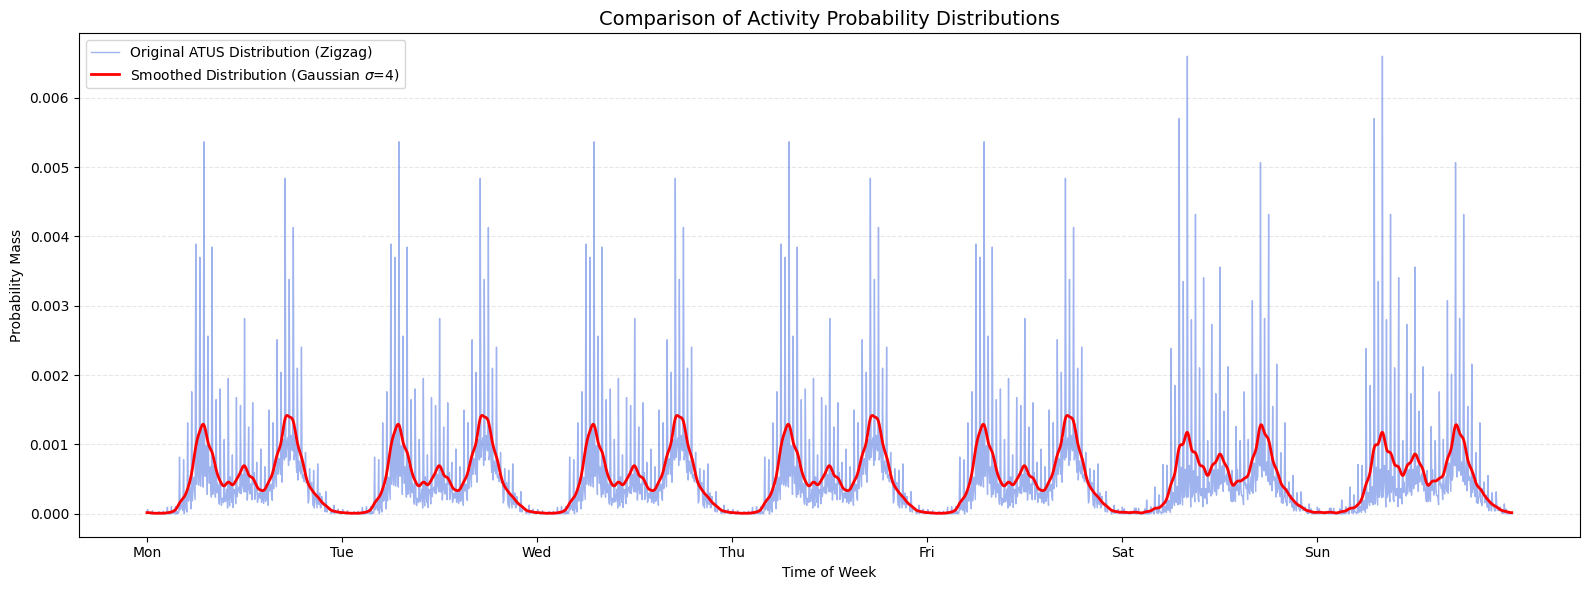

Original Sum: 1.000000
Smoothed Sum: 1.000000


In [18]:


# ---------------------------------------------------------
# 1. APPLY GAUSSIAN SMOOTHING
# ---------------------------------------------------------

sigma_value = 4 

final_week_pdf['prob_smoothed'] = gaussian_filter1d(
    final_week_pdf['probability'], 
    sigma=sigma_value, 
    mode='wrap'
)

# ---------------------------------------------------------
# 2. PLOTTING THE COMPARISON
# ---------------------------------------------------------
plt.figure(figsize=(16, 6))

# Plot the original zigzag data
plt.plot(
    final_week_pdf.index, 
    final_week_pdf['probability'], 
    label='Original ATUS Distribution (Zigzag)', 
    color='royalblue', 
    alpha=0.5, 
    linewidth=1
)

# Plot the smoothed KDE-like curve
plt.plot(
    final_week_pdf.index, 
    final_week_pdf['prob_smoothed'], 
    label=f'Smoothed Distribution (Gaussian $\sigma$={sigma_value})', 
    color='red', 
    linewidth=2
)

# Formatting the X-Axis to show Day Names
# There are 288 bins per day (1440 / 5)
bins_per_day = 1440 // bin_size
day_ticks = [i * bins_per_day for i in range(7)]
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.xticks(day_ticks, day_labels)
plt.title('Comparison of Activity Probability Distributions', fontsize=14)
plt.xlabel('Time of Week')
plt.ylabel('Probability Mass')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. VERIFICATION
# ---------------------------------------------------------
original_sum = final_week_pdf['probability'].sum()
smoothed_sum = final_week_pdf['prob_smoothed'].sum()

print(f"Original Sum: {original_sum:.6f}")
print(f"Smoothed Sum: {smoothed_sum:.6f}")

final_week_pdf.to_csv(f"../data/activity_initial_probability/cooking_start_time_{bin_size}min_bins.csv", index=False)

In [31]:
# 2. Categorize by Day Type (Consistent with your previous logic)
# 1=Sunday, 7=Saturday -> Weekend; 2-6 -> Weekday
cooking['day_type'] = cooking['TUDIARYDAY'].apply(
    lambda x: 'weekend' if x in [1, 7] else 'weekday'
)

# 3. Summarize by Respondent
# We group by TUCASEID to see how many times each person performed the activity.
# We also keep their day_type and TUFINLWGT.
resp_summary = cooking.groupby(['TUCASEID', 'day_type']).agg(
    event_count=('TUCASEID', 'size'),
    weight=('TUFINLWGT', 'first')
).reset_index()

# 4. Identify "Repeaters" (People who did the task 2+ times in one day)
resp_summary['is_repeater'] = (resp_summary['event_count'] > 1).astype(int)

# 5. Calculate Weighted Soft Mask for each Day Type
soft_masks = {}
for dtype in ['weekday', 'weekend']:
    subset = resp_summary[resp_summary['day_type'] == dtype]
    
    total_weighted_active_population = subset['weight'].sum()
    weighted_repeater_population = (subset['is_repeater'] * subset['weight']).sum()
    
    # Calculation: (Mass of Repeaters) / (Total Mass of Active People)
    if total_weighted_active_population > 0:
        soft_masks[dtype] = weighted_repeater_population / total_weighted_active_population
    else:
        soft_masks[dtype] = 0.0

# 6. Output Results
print(f"Weekday Soft Mask Weight: {soft_masks['weekday']:.4f}")
print(f"Weekend Soft Mask Weight: {soft_masks['weekend']:.4f}")

# Optional: Print sample sizes to check data density
counts = resp_summary['day_type'].value_counts()
print(f"\nSample Sizes (Respondents who performed the activity):")
print(f"Weekday: {counts.get('weekday', 0)}")
print(f"Weekend: {counts.get('weekend', 0)}")

Weekday Soft Mask Weight: 0.4523
Weekend Soft Mask Weight: 0.4654

Sample Sizes (Respondents who performed the activity):
Weekday: 5220
Weekend: 4855


## Laundry

In [27]:
laundry = joined_data.where(joined_data['TRCODE'].astype(str) == '020102').dropna()

In [28]:

bin_size = 5  # minutes

# ---------------------------------------------------------
# 1. PREPARE DATA & BINS
# ---------------------------------------------------------
# Convert time string to total minutes since midnight
laundry['start_minutes'] = pd.to_datetime(laundry['TUSTARTTIM'], format='%H:%M:%S').dt.hour * 60 + \
                           pd.to_datetime(laundry['TUSTARTTIM'], format='%H:%M:%S').dt.minute

# Group into bins
laundry['time_bin'] = (laundry['start_minutes'] // bin_size) * bin_size
# Define Day Type
laundry['day_type'] = laundry['TUDIARYDAY'].apply(lambda x: 'weekend' if x in [1, 7] else 'weekday')

# ---------------------------------------------------------
# 2. CALCULATE WEIGHTED VECTORS
# ---------------------------------------------------------

# Create a complete index of all possible bins (0 to 1435) to ensure no gaps (e.g., 3am might be empty)
all_bins = pd.DataFrame({'time_bin': range(0, 1440, bin_size)})

# Sum weights by bin and day_type
grouped = laundry.groupby(['time_bin', 'day_type'])['TUFINLWGT'].sum().reset_index()

# Pivot to separate columns (Weekday vs Weekend mass) and merge with full bin list
pivoted = grouped.pivot(index='time_bin', columns='day_type', values='TUFINLWGT').reset_index()
pivoted = pd.merge(all_bins, pivoted, on='time_bin', how='left').fillna(0)

# Calculate Grand Total Mass
grand_total_mass = laundry['TUFINLWGT'].sum()

# ---------------------------------------------------------
# 3. NORMALIZE TO PROBABILITIES (THE MATH)
# ---------------------------------------------------------

# Probability of event happening in this specific bin on ONE weekday
# (Volume_WD / Total) / 5 days
pivoted['prob_weekday'] = (pivoted['weekday'] / grand_total_mass) / 5.0

# Probability of event happening in this specific bin on ONE weekend day
# (Volume_WE / Total) / 2 days
pivoted['prob_weekend'] = (pivoted['weekend'] / grand_total_mass) / 2.0



# ---------------------------------------------------------
# 4. CONSTRUCT THE 7-DAY VECTOR (Mon -> Sun)
# ---------------------------------------------------------

# Define the week structure (Monday=0 to Sunday=6)
week_structure = [
    ('Monday', 'prob_weekday'),
    ('Tuesday', 'prob_weekday'),
    ('Wednesday', 'prob_weekday'),
    ('Thursday', 'prob_weekday'),
    ('Friday', 'prob_weekday'),
    ('Saturday', 'prob_weekend'),
    ('Sunday', 'prob_weekend')
]

full_week_list = []

for day_name, prob_col in week_structure:
    day_df = pivoted[['time_bin', prob_col]].copy()
    day_df.columns = ['minute_of_day', 'probability'] # Rename for consistency
    day_df['day_of_week'] = day_name
    
    # Create absolute time index for plotting/debugging
    # e.g., Monday 00:05, Tuesday 14:00
    day_df['time_label'] = day_df['minute_of_day'].apply(
        lambda m: f"{day_name} {int(m)//60:02d}:{int(m)%60:02d}"
    )
    
    full_week_list.append(day_df)

# Concatenate into one long list (Monday 00:00 -> Sunday 23:55)
final_week_pdf = pd.concat(full_week_list, ignore_index=True)



<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
/var/folders/hc/35sw0p9s6sdg8k4mnjml0b2m0000gn/T/ipykernel_41098/2810311623.py:32: SyntaxWarning: invalid escape sequence '\s'
  label=f'Smoothed Distribution (Gaussian $\sigma$={sigma_value})',


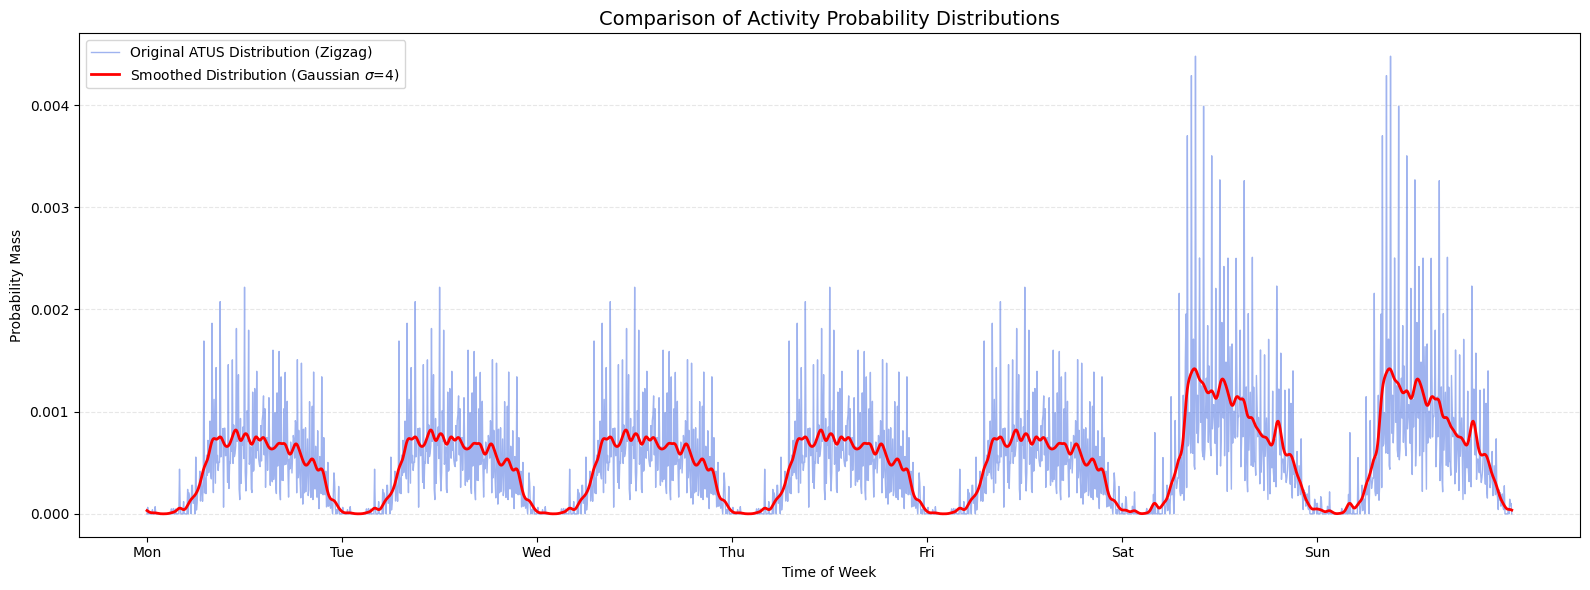

Original Sum: 1.000000
Smoothed Sum: 1.000000


In [29]:


# ---------------------------------------------------------
# 1. APPLY GAUSSIAN SMOOTHING
# ---------------------------------------------------------

sigma_value = 4 

final_week_pdf['prob_smoothed'] = gaussian_filter1d(
    final_week_pdf['probability'], 
    sigma=sigma_value, 
    mode='wrap'
)

# ---------------------------------------------------------
# 2. PLOTTING THE COMPARISON
# ---------------------------------------------------------
plt.figure(figsize=(16, 6))

# Plot the original zigzag data
plt.plot(
    final_week_pdf.index, 
    final_week_pdf['probability'], 
    label='Original ATUS Distribution (Zigzag)', 
    color='royalblue', 
    alpha=0.5, 
    linewidth=1
)

# Plot the smoothed KDE-like curve
plt.plot(
    final_week_pdf.index, 
    final_week_pdf['prob_smoothed'], 
    label=f'Smoothed Distribution (Gaussian $\sigma$={sigma_value})', 
    color='red', 
    linewidth=2
)

# Formatting the X-Axis to show Day Names
# There are 288 bins per day (1440 / 5)
bins_per_day = 1440 // bin_size
day_ticks = [i * bins_per_day for i in range(7)]
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.xticks(day_ticks, day_labels)
plt.title('Comparison of Activity Probability Distributions', fontsize=14)
plt.xlabel('Time of Week')
plt.ylabel('Probability Mass')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. VERIFICATION
# ---------------------------------------------------------
original_sum = final_week_pdf['probability'].sum()
smoothed_sum = final_week_pdf['prob_smoothed'].sum()

print(f"Original Sum: {original_sum:.6f}")
print(f"Smoothed Sum: {smoothed_sum:.6f}")

final_week_pdf.to_csv(f"../data/activity_initial_probability/laundry_start_time_{bin_size}min_bins.csv", index=False)

In [30]:
# 2. Categorize by Day Type (Consistent with your previous logic)
# 1=Sunday, 7=Saturday -> Weekend; 2-6 -> Weekday
laundry['day_type'] = laundry['TUDIARYDAY'].apply(
    lambda x: 'weekend' if x in [1, 7] else 'weekday'
)

# 3. Summarize by Respondent
# We group by TUCASEID to see how many times each person performed the activity.
# We also keep their day_type and TUFINLWGT.
resp_summary = laundry.groupby(['TUCASEID', 'day_type']).agg(
    event_count=('TUCASEID', 'size'),
    weight=('TUFINLWGT', 'first')
).reset_index()

# 4. Identify "Repeaters" (People who did the task 2+ times in one day)
resp_summary['is_repeater'] = (resp_summary['event_count'] > 1).astype(int)

# 5. Calculate Weighted Soft Mask for each Day Type
soft_masks = {}
for dtype in ['weekday', 'weekend']:
    subset = resp_summary[resp_summary['day_type'] == dtype]
    
    total_weighted_active_population = subset['weight'].sum()
    weighted_repeater_population = (subset['is_repeater'] * subset['weight']).sum()
    
    # Calculation: (Mass of Repeaters) / (Total Mass of Active People)
    if total_weighted_active_population > 0:
        soft_masks[dtype] = weighted_repeater_population / total_weighted_active_population
    else:
        soft_masks[dtype] = 0.0

# 6. Output Results
print(f"Weekday Soft Mask Weight: {soft_masks['weekday']:.4f}")
print(f"Weekend Soft Mask Weight: {soft_masks['weekend']:.4f}")

# Optional: Print sample sizes to check data density
counts = resp_summary['day_type'].value_counts()
print(f"\nSample Sizes (Respondents who performed the activity):")
print(f"Weekday: {counts.get('weekday', 0)}")
print(f"Weekend: {counts.get('weekend', 0)}")

Weekday Soft Mask Weight: 0.2260
Weekend Soft Mask Weight: 0.2702

Sample Sizes (Respondents who performed the activity):
Weekday: 1296
Weekend: 1637


## Dishwasher

In [23]:
cleanup = joined_data.where(joined_data['TRCODE'].astype(str) == '020203').dropna()


In [24]:

bin_size = 5  # minutes

# ---------------------------------------------------------
# 1. PREPARE DATA & BINS
# ---------------------------------------------------------
# Convert time string to total minutes since midnight
cleanup['start_minutes'] = pd.to_datetime(cleanup['TUSTARTTIM'], format='%H:%M:%S').dt.hour * 60 + \
                           pd.to_datetime(cleanup['TUSTARTTIM'], format='%H:%M:%S').dt.minute

# Group into bins
cleanup['time_bin'] = (cleanup['start_minutes'] // bin_size) * bin_size
# Define Day Type
cleanup['day_type'] = cleanup['TUDIARYDAY'].apply(lambda x: 'weekend' if x in [1, 7] else 'weekday')

# ---------------------------------------------------------
# 2. CALCULATE WEIGHTED VECTORS
# ---------------------------------------------------------

# Create a complete index of all possible bins (0 to 1435) to ensure no gaps (e.g., 3am might be empty)
all_bins = pd.DataFrame({'time_bin': range(0, 1440, bin_size)})

# Sum weights by bin and day_type
grouped = cleanup.groupby(['time_bin', 'day_type'])['TUFINLWGT'].sum().reset_index()

# Pivot to separate columns (Weekday vs Weekend mass) and merge with full bin list
pivoted = grouped.pivot(index='time_bin', columns='day_type', values='TUFINLWGT').reset_index()
pivoted = pd.merge(all_bins, pivoted, on='time_bin', how='left').fillna(0)

# Calculate Grand Total Mass
grand_total_mass = cleanup['TUFINLWGT'].sum()

# ---------------------------------------------------------
# 3. NORMALIZE TO PROBABILITIES (THE MATH)
# ---------------------------------------------------------

# Probability of event happening in this specific bin on ONE weekday
# (Volume_WD / Total) / 5 days
pivoted['prob_weekday'] = (pivoted['weekday'] / grand_total_mass) / 5.0

# Probability of event happening in this specific bin on ONE weekend day
# (Volume_WE / Total) / 2 days
pivoted['prob_weekend'] = (pivoted['weekend'] / grand_total_mass) / 2.0



# ---------------------------------------------------------
# 4. CONSTRUCT THE 7-DAY VECTOR (Mon -> Sun)
# ---------------------------------------------------------

# Define the week structure (Monday=0 to Sunday=6)
week_structure = [
    ('Monday', 'prob_weekday'),
    ('Tuesday', 'prob_weekday'),
    ('Wednesday', 'prob_weekday'),
    ('Thursday', 'prob_weekday'),
    ('Friday', 'prob_weekday'),
    ('Saturday', 'prob_weekend'),
    ('Sunday', 'prob_weekend')
]

full_week_list = []

for day_name, prob_col in week_structure:
    day_df = pivoted[['time_bin', prob_col]].copy()
    day_df.columns = ['minute_of_day', 'probability'] # Rename for consistency
    day_df['day_of_week'] = day_name
    
    # Create absolute time index for plotting/debugging
    # e.g., Monday 00:05, Tuesday 14:00
    day_df['time_label'] = day_df['minute_of_day'].apply(
        lambda m: f"{day_name} {int(m)//60:02d}:{int(m)%60:02d}"
    )
    
    full_week_list.append(day_df)

# Concatenate into one long list (Monday 00:00 -> Sunday 23:55)
final_week_pdf = pd.concat(full_week_list, ignore_index=True)


<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
/var/folders/hc/35sw0p9s6sdg8k4mnjml0b2m0000gn/T/ipykernel_41098/744869385.py:32: SyntaxWarning: invalid escape sequence '\s'
  label=f'Smoothed Distribution (Gaussian $\sigma$={sigma_value})',


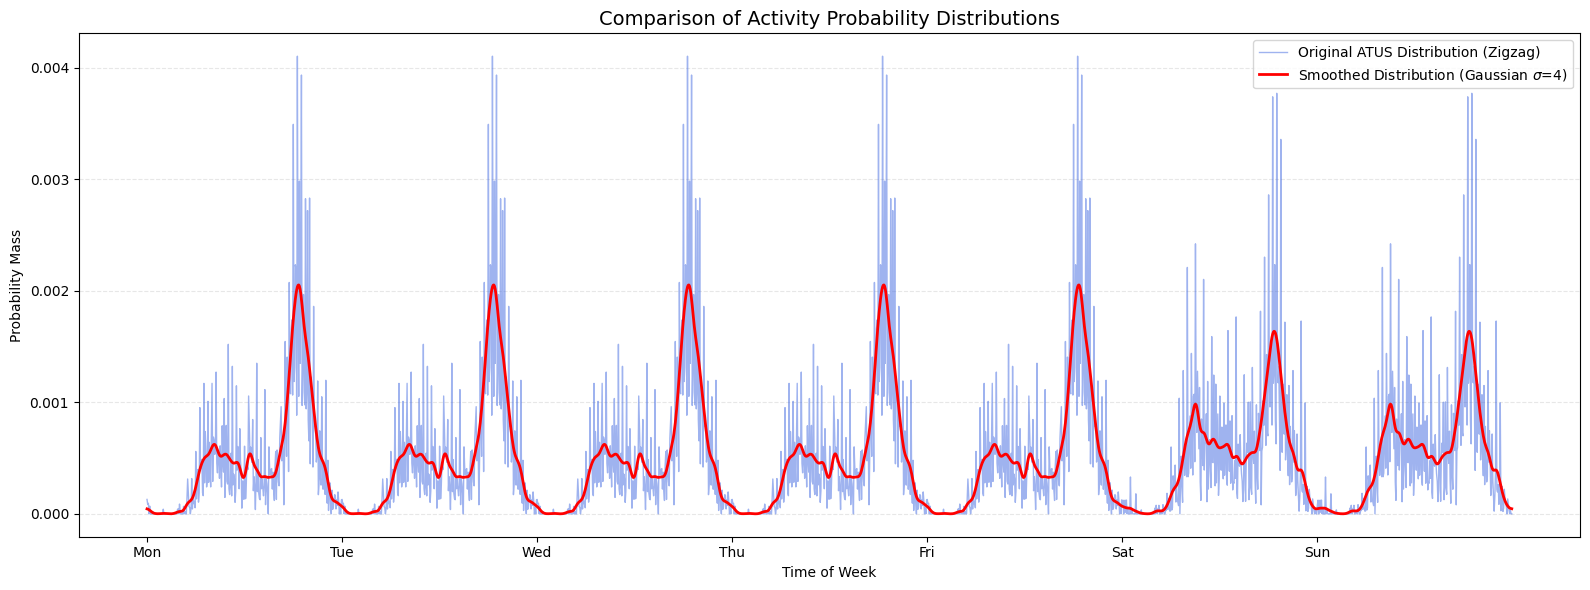

Original Sum: 1.000000
Smoothed Sum: 1.000000


In [25]:


# ---------------------------------------------------------
# 1. APPLY GAUSSIAN SMOOTHING
# ---------------------------------------------------------

sigma_value = 4 

final_week_pdf['prob_smoothed'] = gaussian_filter1d(
    final_week_pdf['probability'], 
    sigma=sigma_value, 
    mode='wrap'
)

# ---------------------------------------------------------
# 2. PLOTTING THE COMPARISON
# ---------------------------------------------------------
plt.figure(figsize=(16, 6))

# Plot the original zigzag data
plt.plot(
    final_week_pdf.index, 
    final_week_pdf['probability'], 
    label='Original ATUS Distribution (Zigzag)', 
    color='royalblue', 
    alpha=0.5, 
    linewidth=1
)

# Plot the smoothed KDE-like curve
plt.plot(
    final_week_pdf.index, 
    final_week_pdf['prob_smoothed'], 
    label=f'Smoothed Distribution (Gaussian $\sigma$={sigma_value})', 
    color='red', 
    linewidth=2
)

# Formatting the X-Axis to show Day Names
# There are 288 bins per day (1440 / 5)
bins_per_day = 1440 // bin_size
day_ticks = [i * bins_per_day for i in range(7)]
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.xticks(day_ticks, day_labels)
plt.title('Comparison of Activity Probability Distributions', fontsize=14)
plt.xlabel('Time of Week')
plt.ylabel('Probability Mass')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. VERIFICATION
# ---------------------------------------------------------
original_sum = final_week_pdf['probability'].sum()
smoothed_sum = final_week_pdf['prob_smoothed'].sum()

print(f"Original Sum: {original_sum:.6f}")
print(f"Smoothed Sum: {smoothed_sum:.6f}")

final_week_pdf.to_csv(f"../data/activity_initial_probability/dishwasher_start_time_{bin_size}min_bins.csv", index=False)

# For Weekend Occupancy

In [3]:
# Read only the column names (first row)
data2023 = pd.read_csv(fr"atusact-2023/atusact_2023.dat", dtype={'TRCODE': str, 'TUCASEID': str})
respondents2023 = pd.read_csv(fr"atusresp-2023/atusresp_2023.dat", dtype={'TUCASEID': str})
jointed_data2023 = pd.merge(data2023, respondents2023, on='TUCASEID', how='inner')
data2024 = pd.read_csv(fr"atusact-2024/atusact_2024.dat", dtype={'TRCODE': str, 'TUCASEID': str})
respondents2024 = pd.read_csv(fr"atusresp-2024/atusresp_2024.dat", dtype={'TUCASEID': str})
joined_data2024 = pd.merge(data2024, respondents2024, on='TUCASEID', how='inner')
joined_data = pd.concat([jointed_data2023, joined_data2024], ignore_index=True)

## College Student

In [192]:
#college_student = joined_data[joined_data['TESCHLVL'] == 1]
role= joined_data[joined_data['TESCHLVL'] == 1] # high school
#role= joined_data[joined_data['TESCHLVL'] == 2] # college student
#role = joined_data[(joined_data['TELFS'] == 1) & (joined_data['TRDPFTPT'] == 1)] # employed
#role = joined_data[(joined_data['TELFS'] == 5)] # retired
# Filter college students and prepare data for both weekday and weekend
role = role.copy()
role['day_type'] = role['TUDIARYDAY'].apply(
    lambda x: 'weekend' if x in [1, 7] else 'weekday'
)

# Filter valid location data (TEWHERE > 0 and < 80)
role_valid = role[(role['TEWHERE'] > 0) & (role['TEWHERE'] < 80)].copy()

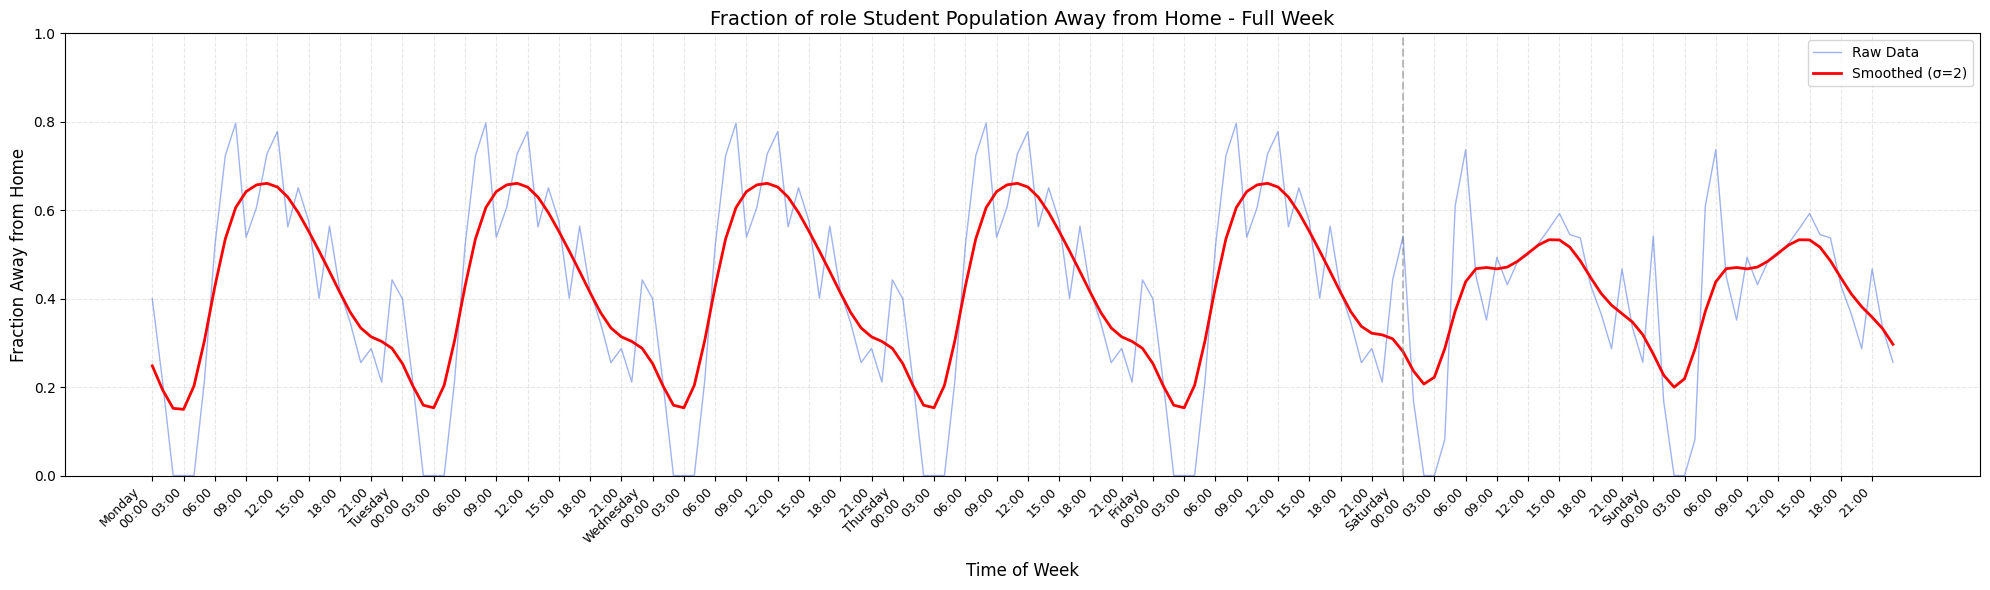

OCCUPANCY ANALYSIS - COLLEGE STUDENTS
--------------------------------------------------------------------------------
Total Sample Size: 2041 activity records
Total Weighted Population: 90,362,344,558
Average Fraction Away from Home: 0.426
Peak Fraction Away: 0.661
Minimum Fraction Away: 0.150
--------------------------------------------------------------------------------
Total Sample Size: 2082 activity records
Total Weighted Population: 38,648,326,824
Average Fraction Away from Home: 0.406
Peak Fraction Away: 0.533
Minimum Fraction Away: 0.200



In [193]:
bin_size = 60  # minutes

# Convert time string to total minutes since midnight
role_valid['start_minutes'] = pd.to_datetime(role_valid['TUSTARTTIM'], format='%H:%M:%S').dt.hour * 60 + \
                           pd.to_datetime(role_valid['TUSTARTTIM'], format='%H:%M:%S').dt.minute

# Group into bins
role_valid['time_bin'] = (role_valid['start_minutes'] // bin_size) * bin_size
role_valid['away_from_home'] = (role_valid['TEWHERE'] > 1).astype(int)

# ---------------------------------------------------------
# 2. CREATE TIME BINS FOR ENTIRE WEEK
# ---------------------------------------------------------
# Create a complete index of all possible bins (0 to 1435 minutes)
all_bins = pd.DataFrame({'time_bin': range(0, 1440, bin_size)})

# ---------------------------------------------------------
# 3. CALCULATE WEIGHTED MASS AT HOME vs AWAY FOR EACH DAY TYPE
# ---------------------------------------------------------
occupancy_by_day_type = {}

for dtype in ['weekday', 'weekend']:
    day_data = role_valid[role_valid['day_type'] == dtype]
    
    # Group by time_bin and away_from_home status, sum the weights
    grouped = day_data.groupby(['time_bin', 'away_from_home'])['TUFINLWGT'].sum().reset_index()
    
    # Pivot to separate columns (at_home=0 vs away=1)
    pivoted = grouped.pivot(index='time_bin', columns='away_from_home', values='TUFINLWGT').reset_index()
    pivoted.columns = ['time_bin', 'weight_at_home', 'weight_away']
    
    # Merge with complete bin list to fill gaps
    pivoted = pd.merge(all_bins, pivoted, on='time_bin', how='left').fillna(0)
    
    # ---------------------------------------------------------
    # 4. CALCULATE FRACTION AWAY FROM HOME
    # ---------------------------------------------------------
    # At each time bin, fraction away = weight_away / (weight_at_home + weight_away)
    pivoted['total_weight'] = pivoted['weight_at_home'] + pivoted['weight_away']
    pivoted['fraction_away'] = pivoted['weight_away'] / pivoted['total_weight']
    
    # Handle division by zero (when no activities recorded)
    pivoted['fraction_away'] = pivoted['fraction_away'].fillna(0)
    
    occupancy_by_day_type[dtype] = pivoted

# ---------------------------------------------------------
# 5. CONSTRUCT 7-DAY WEEK VECTOR
# ---------------------------------------------------------
week_structure = [
    ('Monday', 'weekday'),
    ('Tuesday', 'weekday'),
    ('Wednesday', 'weekday'),
    ('Thursday', 'weekday'),
    ('Friday', 'weekday'),
    ('Saturday', 'weekend'),
    ('Sunday', 'weekend')
]

full_week_list = []

for day_name, day_type in week_structure:
    pivoted = occupancy_by_day_type[day_type]
    
    day_df = pd.DataFrame({
        'minute_of_day': pivoted['time_bin'].values,
        'fraction_away_from_home': pivoted['fraction_away'].values,
        'day_of_week': day_name,
        'day_type': day_type
    })
    
    day_df['time_label'] = day_df['minute_of_day'].apply(
        lambda m: f"{day_name} {int(m)//60:02d}:{int(m)%60:02d}"
    )
    
    full_week_list.append(day_df)

# Concatenate into one long list (Monday 00:00 -> Sunday 23:55)
weekly_occupancy = pd.concat(full_week_list, ignore_index=True)

# ---------------------------------------------------------
# 6. APPLY GAUSSIAN SMOOTHING
# ---------------------------------------------------------
sigma_value = 2

weekly_occupancy['fraction_away_smoothed'] = gaussian_filter1d(
    weekly_occupancy['fraction_away_from_home'], 
    sigma=sigma_value, 
    mode='wrap'
)

# ---------------------------------------------------------
# 7. PLOT THE RESULTS - FULL WEEK
# ---------------------------------------------------------
plt.figure(figsize=(20, 6))

# Plot original data
plt.plot(
    weekly_occupancy.index, 
    weekly_occupancy['fraction_away_from_home'], 
    label='Raw Data', 
    color='royalblue', 
    alpha=0.5, 
    linewidth=1
)

# Plot smoothed curve
plt.plot(
    weekly_occupancy.index, 
    weekly_occupancy['fraction_away_smoothed'], 
    label=f'Smoothed (σ={sigma_value})', 
    color='red', 
    linewidth=2
)

# Add vertical lines to separate weekday/weekend
bins_per_day = 1440 // bin_size
friday_end = 5 * bins_per_day
plt.axvline(friday_end, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)

# Formatting with both day names and hour labels
# Create x-tick positions for every 3 hours on each day
xtick_positions = []
xtick_labels = []

for day_idx, (day_name, _) in enumerate(week_structure):
    # Add main day label at midnight
    xtick_positions.append(day_idx * bins_per_day)
    xtick_labels.append(f'{day_name}\n00:00')
    
    # Add hour labels every 3 hours (3h, 6h, 9h, 12h, 15h, 18h, 21h)
    for hour in [3, 6, 9, 12, 15, 18, 21]:
        bin_index = day_idx * bins_per_day + (hour * 60) // bin_size
        xtick_positions.append(bin_index)
        xtick_labels.append(f'{hour:02d}:00')

plt.xticks(xtick_positions, xtick_labels, rotation=45, ha='right', fontsize=9)
plt.title('Fraction of role Student Population Away from Home - Full Week', fontsize=14)
plt.xlabel('Time of Week', fontsize=12)
plt.ylabel('Fraction Away from Home', fontsize=12)
plt.ylim(0, 1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 8. SUMMARY STATISTICS
# ---------------------------------------------------------
print("="*80)
print("OCCUPANCY ANALYSIS - COLLEGE STUDENTS")
print("="*80)

for dtype in ['weekday', 'weekend']:
    day_data = role_valid[role_valid['day_type'] == dtype]
    occupancy_data = weekly_occupancy[weekly_occupancy['day_type'] == dtype]
    print("-"*80)
    print(f"Total Sample Size: {len(day_data)} activity records")
    print(f"Total Weighted Population: {day_data['TUFINLWGT'].sum():,.0f}")
    print(f"Average Fraction Away from Home: {occupancy_data['fraction_away_smoothed'].mean():.3f}")
    print(f"Peak Fraction Away: {occupancy_data['fraction_away_smoothed'].max():.3f}")
    print(f"Minimum Fraction Away: {occupancy_data['fraction_away_smoothed'].min():.3f}")

print()
print("="*80)

# Leaving Home Trip Analysis

In [77]:
# =========================================================================
# LEAVING HOME TRIP ANALYSIS - WEEKDAY VS WEEKEND
# =========================================================================

# Step 1: Filter for activities where location is NOT home (TEWHERE > 1)
# TEWHERE: 1 = respondent's home, 2+ = away from home

# Categorize by day type
joined_data['day_type'] = joined_data['TUDIARYDAY'].apply(
    lambda x: 'weekend' if x in [1, 7] else 'weekday'
)

# Group by respondent to analyze their daily trips
# For each respondent on each day, we look at their activities

# Step 2: For each respondent, determine if they went out
# Count unique respondents per day type
all_respondents = joined_data.groupby(['TUCASEID', 'day_type']).agg(
    weight=('TUFINLWGT', 'first')
).reset_index()

# Identify who went out (has any activity with TEWHERE > 1)
went_out = joined_data[joined_data['TEWHERE'] > 1].groupby(['TUCASEID', 'day_type']).agg(
    went_out_flag=('TUCASEID', 'size'),
    weight=('TUFINLWGT', 'first'),
    total_time_out=('TUACTDUR', 'sum')  # Total minutes spent away from home
).reset_index()

# Merge to get all respondents (including those who stayed home)
trip_analysis = pd.merge(
    all_respondents, 
    went_out[['TUCASEID', 'day_type', 'went_out_flag', 'total_time_out']], 
    on=['TUCASEID', 'day_type'], 
    how='left'
).fillna({'went_out_flag': 0, 'total_time_out': 0})

# Mark who went out
trip_analysis['went_out'] = (trip_analysis['went_out_flag'] > 0).astype(int)

print("="*80)
print("LEAVING HOME TRIP ANALYSIS")
print("="*80)

# Calculate weighted statistics for each day type
for day_type in ['weekday', 'weekend']:
    subset = trip_analysis[trip_analysis['day_type'] == day_type]
    
    total_population = subset['weight'].sum()
    stayed_home_population = subset[subset['went_out'] == 0]['weight'].sum()
    went_out_population = subset[subset['went_out'] == 1]['weight'].sum()
    
    prob_stay_home = stayed_home_population / total_population
    prob_go_out = went_out_population / total_population
    
    print(f"\n{day_type.upper()}:")
    print("-"*80)
    print(f"Total weighted population: {total_population:,.0f}")
    print(f"Stayed home population: {stayed_home_population:,.0f} ({prob_stay_home:.2%})")
    print(f"Went out population: {went_out_population:,.0f} ({prob_go_out:.2%})")
    print()
    
    # For those who went out, calculate average time away
    went_out_subset = subset[subset['went_out'] == 1]
    if len(went_out_subset) > 0:
        weighted_avg_time_out = np.average(
            went_out_subset['total_time_out'], 
            weights=went_out_subset['weight']
        )
        print(f"Average time away from home (for those who went out): {weighted_avg_time_out:.1f} minutes ({weighted_avg_time_out/60:.1f} hours)")
    
    print()

print("="*80)

LEAVING HOME TRIP ANALYSIS

WEEKDAY:
--------------------------------------------------------------------------------
Total weighted population: 142,049,635,337
Stayed home population: 22,592,581,817 (15.90%)
Went out population: 119,457,053,520 (84.10%)

Average time away from home (for those who went out): 451.8 minutes (7.5 hours)


WEEKEND:
--------------------------------------------------------------------------------
Total weighted population: 56,874,304,706
Stayed home population: 12,781,765,240 (22.47%)
Went out population: 44,092,539,466 (77.53%)

Average time away from home (for those who went out): 362.2 minutes (6.0 hours)



In [82]:
# =========================================================================
# TRIP FREQUENCY ANALYSIS - OUT ONCE VS OUT MULTIPLE TIMES
# =========================================================================

# For people who went out, analyze how many separate trips they made
# A "trip" is defined as a transition from home (TEWHERE=1) to away (TEWHERE>1)
# Only count as separate trip if gap between return and next leave is >= 30 minutes

def count_trips_with_gap_threshold(respondent_data, min_gap_minutes=30):
    """
    Count the number of trips (leaving home events) for a respondent
    by detecting transitions from home to away, but only counting as
    separate trips if they stayed home for at least min_gap_minutes
    """
    # Sort activities by start time
    respondent_data = respondent_data.sort_values('TUSTARTTIM').reset_index(drop=True)
    
    if len(respondent_data) == 0:
        return 0
    
    # Convert start time to minutes since midnight
    respondent_data['start_minutes'] = pd.to_datetime(
        respondent_data['TUSTARTTIM'], format='%H:%M:%S'
    ).dt.hour * 60 + pd.to_datetime(
        respondent_data['TUSTARTTIM'], format='%H:%M:%S'
    ).dt.minute
    
    # Add end time
    respondent_data['end_minutes'] = respondent_data['start_minutes'] + respondent_data['TUACTDUR']
    
    # Create binary: 1 = at home, 0 = away
    respondent_data['at_home'] = (respondent_data['TEWHERE'] == 1).astype(int)
    
    trips = 0
    last_return_time = None  # Track when we last returned home
    currently_away = False
    
    for idx, row in respondent_data.iterrows():
        if row['at_home'] == 0:  # Activity away from home
            if not currently_away:
                # Starting a new away period
                # Check if enough time has passed since last return
                if last_return_time is None or (row['start_minutes'] - last_return_time) >= min_gap_minutes:
                    trips += 1
                    currently_away = True
                # If gap < min_gap_minutes, this is considered part of the same trip
                else:
                    # Still part of previous trip, don't increment
                    currently_away = True
        else:  # Activity at home
            if currently_away:
                # Just returned home
                last_return_time = row['start_minutes']
                currently_away = False
    
    return trips

# Count trips for each respondent
trip_counts = []

current_data = joined_data[joined_data['TRDPFTPT']==1]

for (case_id, day_type), group in current_data.groupby(['TUCASEID', 'day_type']):
    num_trips = count_trips_with_gap_threshold(group, min_gap_minutes=30)
    weight = group['TUFINLWGT'].iloc[0]
    
    trip_counts.append({
        'TUCASEID': case_id,
        'day_type': day_type,
        'num_trips': num_trips,
        'weight': weight
    })

trip_counts_df = pd.DataFrame(trip_counts)

print("="*80)
print("TRIP FREQUENCY ANALYSIS - FOR PEOPLE WHO WENT OUT")
print("(Trips separated by < 30 min at home are counted as one trip)")
print("="*80)

for day_type in ['weekday', 'weekend']:
    subset = trip_counts_df[trip_counts_df['day_type'] == day_type]
    
    # Filter for people who went out (num_trips > 0)
    went_out_subset = subset[subset['num_trips'] > 0]
    
    if len(went_out_subset) == 0:
        print(f"\n{day_type.upper()}: No data")
        continue
    
    total_went_out = went_out_subset['weight'].sum()
    
    # Calculate distribution
    out_once = went_out_subset[went_out_subset['num_trips'] == 1]['weight'].sum()
    out_multiple = went_out_subset[went_out_subset['num_trips'] > 1]['weight'].sum()
    
    prob_out_once = out_once / total_went_out
    prob_out_multiple = out_multiple / total_went_out
    
    print(f"\n{day_type.upper()}:")
    print("-"*80)
    print(f"Among those who went out:")
    print(f"  Out once: {out_once:,.0f} ({prob_out_once:.2%})")
    print(f"  Out multiple times: {out_multiple:,.0f} ({prob_out_multiple:.2%})")
    print()
    
    # Detailed breakdown
    print("Detailed trip frequency distribution:")
    trip_freq = went_out_subset.groupby('num_trips').agg(
        count=('TUCASEID', 'size'),
        weighted_population=('weight', 'sum')
    ).reset_index()
    trip_freq['percentage'] = (trip_freq['weighted_population'] / total_went_out * 100)
    
    for _, row in trip_freq.head(10).iterrows():
        print(f"  {int(row['num_trips'])} trip(s): {row['weighted_population']:,.0f} ({row['percentage']:.1f}%) - {int(row['count'])} respondents")
    
    # Average number of trips
    weighted_avg_trips = np.average(went_out_subset['num_trips'], weights=went_out_subset['weight'])
    print(f"\n  Average number of trips (for those who went out): {weighted_avg_trips:.2f}")
    
    print()

print("="*80)

TRIP FREQUENCY ANALYSIS - FOR PEOPLE WHO WENT OUT
(Trips separated by < 30 min at home are counted as one trip)

WEEKDAY:
--------------------------------------------------------------------------------
Among those who went out:
  Out once: 6,010,129,944 (8.27%)
  Out multiple times: 66,637,158,376 (91.73%)

Detailed trip frequency distribution:
  1 trip(s): 6,010,129,944 (8.3%) - 290 respondents
  2 trip(s): 24,919,185,168 (34.3%) - 1265 respondents
  3 trip(s): 24,570,169,025 (33.8%) - 1365 respondents
  4 trip(s): 12,411,020,570 (17.1%) - 691 respondents
  5 trip(s): 3,820,227,278 (5.3%) - 204 respondents
  6 trip(s): 805,393,775 (1.1%) - 44 respondents
  7 trip(s): 80,311,961 (0.1%) - 7 respondents
  8 trip(s): 30,850,599 (0.0%) - 2 respondents

  Average number of trips (for those who went out): 2.81


WEEKEND:
--------------------------------------------------------------------------------
Among those who went out:
  Out once: 2,534,389,932 (8.97%)
  Out multiple times: 25,719,21

In [80]:
# =========================================================================
# SUMMARY TABLE
# =========================================================================

summary_data = []

for day_type in ['weekday', 'weekend']:
    # Get stay home vs go out probabilities
    subset = trip_analysis[trip_analysis['day_type'] == day_type]
    total_pop = subset['weight'].sum()
    stayed_home_pop = subset[subset['went_out'] == 0]['weight'].sum()
    went_out_pop = subset[subset['went_out'] == 1]['weight'].sum()
    
    prob_stay = stayed_home_pop / total_pop
    prob_out = went_out_pop / total_pop
    
    # Get average time out
    went_out_subset = subset[subset['went_out'] == 1]
    avg_time_out = np.average(went_out_subset['total_time_out'], weights=went_out_subset['weight'])
    
    # Get trip frequency
    trip_subset = trip_counts_df[trip_counts_df['day_type'] == day_type]
    went_out_trip_subset = trip_subset[trip_subset['num_trips'] > 0]
    
    out_once_pop = went_out_trip_subset[went_out_trip_subset['num_trips'] == 1]['weight'].sum()
    out_multiple_pop = went_out_trip_subset[went_out_trip_subset['num_trips'] > 1]['weight'].sum()
    
    prob_once = out_once_pop / went_out_pop if went_out_pop > 0 else 0
    prob_multiple = out_multiple_pop / went_out_pop if went_out_pop > 0 else 0
    
    avg_trips = np.average(went_out_trip_subset['num_trips'], weights=went_out_trip_subset['weight'])
    
    summary_data.append({
        'Day Type': day_type.capitalize(),
        'P(Stay Home)': f"{prob_stay:.1%}",
        'P(Go Out)': f"{prob_out:.1%}",
        'Avg Time Out (hrs)': f"{avg_time_out/60:.1f}",
        'P(Out Once | Went Out)': f"{prob_once:.1%}",
        'P(Out Multiple | Went Out)': f"{prob_multiple:.1%}",
        'Avg # Trips': f"{avg_trips:.2f}"
    })

summary_df = pd.DataFrame(summary_data)

print("="*80)
print("SUMMARY: LEAVING HOME BEHAVIOR - WEEKDAY VS WEEKEND")
print("="*80)
print()
print(summary_df.to_string(index=False))
print()
print("="*80)

SUMMARY: LEAVING HOME BEHAVIOR - WEEKDAY VS WEEKEND

Day Type P(Stay Home) P(Go Out) Avg Time Out (hrs) P(Out Once | Went Out) P(Out Multiple | Went Out) Avg # Trips
 Weekday        15.9%     84.1%                7.5                   9.6%                     109.3%        2.95
 Weekend        22.5%     77.5%                6.0                  11.1%                     117.9%        2.96



In [83]:
# =========================================================================
# AWAY DURATION DISTRIBUTION ANALYSIS
# =========================================================================

# For people who went out, analyze the distribution of total time spent away

print("="*80)
print("AWAY DURATION DISTRIBUTION ANALYSIS")
print("="*80)

for day_type in ['weekday', 'weekend']:
    subset = trip_analysis[trip_analysis['day_type'] == day_type]
    
    # Filter for people who went out
    went_out_subset = subset[subset['went_out'] == 1].copy()
    
    if len(went_out_subset) == 0:
        print(f"\n{day_type.upper()}: No data")
        continue
    
    # Convert to hours for easier interpretation
    went_out_subset['total_time_out_hours'] = went_out_subset['total_time_out'] / 60
    
    # Calculate weighted statistics
    durations = went_out_subset['total_time_out_hours']
    weights = went_out_subset['weight']
    
    weighted_mean = np.average(durations, weights=weights)
    variance = np.average((durations - weighted_mean)**2, weights=weights)
    weighted_std = np.sqrt(variance)
    
    # Weighted percentiles
    sorted_data = went_out_subset.sort_values('total_time_out_hours')
    cumsum_weights = sorted_data['weight'].cumsum()
    total_weight = sorted_data['weight'].sum()
    
    percentiles = [10, 25, 50, 75, 90, 95, 98]
    percentile_values = {}
    
    for p in percentiles:
        target_weight = total_weight * (p / 100)
        idx = (cumsum_weights >= target_weight).idxmax()
        percentile_values[p] = sorted_data.loc[idx, 'total_time_out_hours']
    
    print(f"\n{day_type.upper()}:")
    print("-"*80)
    print(f"Sample size: {len(went_out_subset)} respondents")
    print(f"Total weighted population: {total_weight:,.0f}")
    print()
    print(f"Weighted Mean: {weighted_mean:.2f} hours")
    print(f"Weighted Std Dev: {weighted_std:.2f} hours")
    print()
    print("Weighted Percentiles:")
    for p in percentiles:
        print(f"  {p}th percentile: {percentile_values[p]:.2f} hours")
    
    print()

print("="*80)

AWAY DURATION DISTRIBUTION ANALYSIS

WEEKDAY:
--------------------------------------------------------------------------------
Sample size: 6755 respondents
Total weighted population: 119,457,053,520

Weighted Mean: 7.53 hours
Weighted Std Dev: 4.45 hours

Weighted Percentiles:
  10th percentile: 1.50 hours
  25th percentile: 3.33 hours
  50th percentile: 8.17 hours
  75th percentile: 10.92 hours
  90th percentile: 13.03 hours
  95th percentile: 14.25 hours
  98th percentile: 15.58 hours


WEEKEND:
--------------------------------------------------------------------------------
Sample size: 6111 respondents
Total weighted population: 44,092,539,466

Weighted Mean: 6.04 hours
Weighted Std Dev: 4.15 hours

Weighted Percentiles:
  10th percentile: 1.25 hours
  25th percentile: 2.67 hours
  50th percentile: 5.25 hours
  75th percentile: 8.75 hours
  90th percentile: 12.00 hours
  95th percentile: 13.67 hours
  98th percentile: 15.58 hours



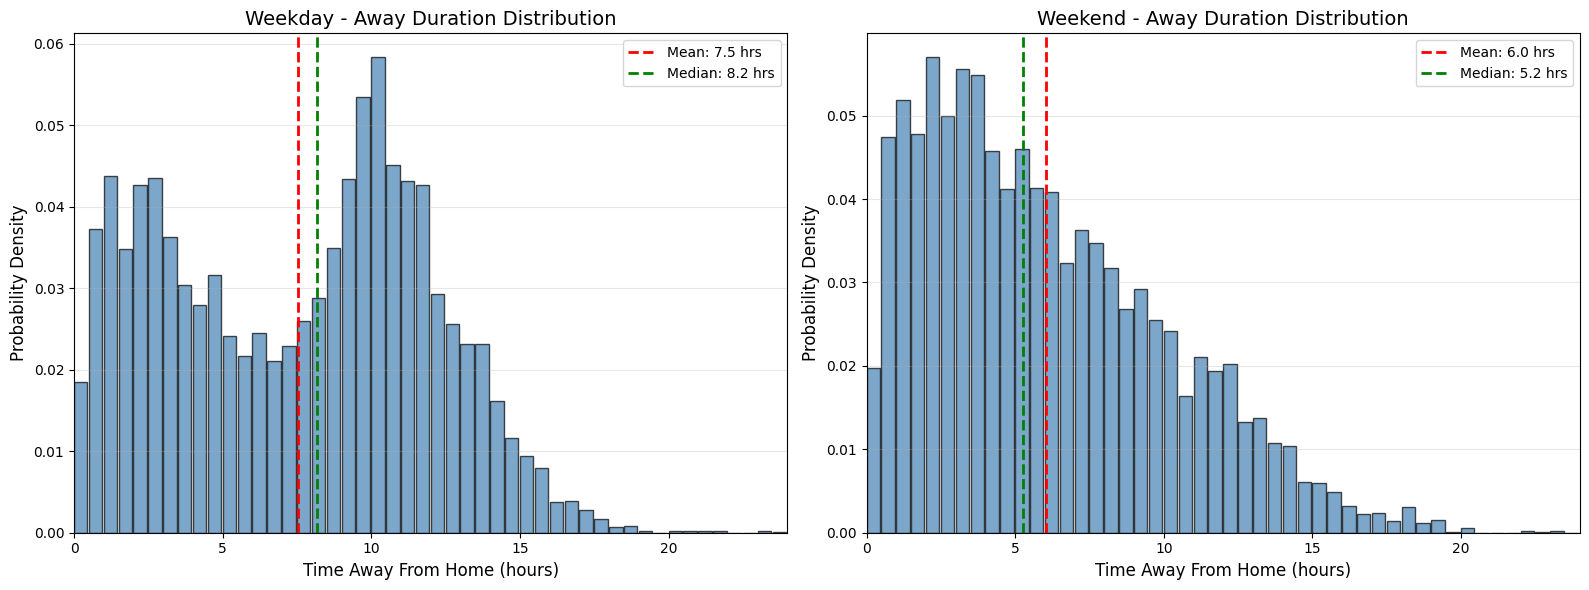

Distribution plotted: 0-24 hours in 0.5-hour bins


In [84]:
# =========================================================================
# VISUALIZE AWAY DURATION DISTRIBUTION
# =========================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, day_type in enumerate(['weekday', 'weekend']):
    subset = trip_analysis[trip_analysis['day_type'] == day_type]
    went_out_subset = subset[subset['went_out'] == 1].copy()
    went_out_subset['total_time_out_hours'] = went_out_subset['total_time_out'] / 60
    
    # Create weighted histogram
    # Bin the data
    bins = np.arange(0, 24.5, 0.5)  # 0 to 24 hours in 0.5-hour bins
    
    # Calculate weighted histogram
    hist_weights = []
    for i in range(len(bins) - 1):
        mask = (went_out_subset['total_time_out_hours'] >= bins[i]) & \
               (went_out_subset['total_time_out_hours'] < bins[i+1])
        hist_weights.append(went_out_subset[mask]['weight'].sum())
    
    # Normalize to get probability density
    total_weight = went_out_subset['weight'].sum()
    hist_probs = np.array(hist_weights) / total_weight
    
    # Plot
    ax = axes[idx]
    ax.bar(bins[:-1], hist_probs, width=0.45, align='edge', 
           alpha=0.7, color='steelblue', edgecolor='black')
    
    # Add statistics lines
    weighted_mean = np.average(went_out_subset['total_time_out_hours'], 
                               weights=went_out_subset['weight'])
    ax.axvline(weighted_mean, color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {weighted_mean:.1f} hrs')
    
    # Median
    sorted_data = went_out_subset.sort_values('total_time_out_hours')
    cumsum_weights = sorted_data['weight'].cumsum()
    median_idx = (cumsum_weights >= total_weight / 2).idxmax()
    median_val = sorted_data.loc[median_idx, 'total_time_out_hours']
    ax.axvline(median_val, color='green', linestyle='--', linewidth=2,
               label=f'Median: {median_val:.1f} hrs')
    
    ax.set_xlabel('Time Away From Home (hours)', fontsize=12)
    ax.set_ylabel('Probability Density', fontsize=12)
    ax.set_title(f'{day_type.capitalize()} - Away Duration Distribution', fontsize=14)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_xlim(0, 24)

plt.tight_layout()
plt.show()

print("Distribution plotted: 0-24 hours in 0.5-hour bins")